In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
csv_file = "dimer_pose_data.csv"  # <-- 换成你的CSV路径
df = pd.read_csv(csv_file)
print(df.head())

             file_name  cluster_num  cluster_member  member_energy  \
0  seed-1-28-1-2-1.crd            0               1      12.228715   
1  seed-1-30-1-2-1.crd            0               2      20.016536   
2  seed-1-32-0-0-0.crd            1               1      15.129034   
3  seed-1-31-1-2-0.crd            2               1      15.467624   
4  seed-1-31-1-0-2.crd            3               1      16.713331   

   member_score    spdg      rmsd    polar  nonpolar    inter  polar15  
0     12.228715 -7.2618  698.9668  10.5106  -41.3854 -30.8748 -25.6195  
1     20.016536 -6.8316  698.9867  11.2024  -37.2850 -26.0825 -20.4813  
2     15.129034 -6.8140  693.3856   6.8558  -34.2869 -27.4312 -24.0033  
3     15.467624 -6.8600  696.5327   9.1946  -36.2869 -27.0924 -22.4951  
4     16.713331 -6.9257  693.8402  12.8687  -39.3582 -26.4895 -20.0551  


In [4]:
print("数据概览:")
print(df.info())
print("\n数值列的描述性统计:")
print(df.describe())


数据概览:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   file_name       69 non-null     object 
 1   cluster_num     69 non-null     int64  
 2   cluster_member  69 non-null     int64  
 3   member_energy   69 non-null     float64
 4   member_score    69 non-null     float64
 5   spdg            69 non-null     float64
 6   rmsd            69 non-null     float64
 7   polar           69 non-null     float64
 8   nonpolar        69 non-null     float64
 9   inter           69 non-null     float64
 10  polar15         69 non-null     float64
dtypes: float64(8), int64(2), object(1)
memory usage: 6.1+ KB
None

数值列的描述性统计:
       cluster_num  cluster_member  member_energy  member_score       spdg  \
count     69.00000       69.000000      69.000000     69.000000  69.000000   
mean      23.73913        1.391304      23.926652     23.926652  -6.361

In [5]:
unique_clusters = df['cluster_num'].unique()
print(f"\n共检测到 {len(unique_clusters)} 个 cluster_num: {unique_clusters}")


共检测到 50 个 cluster_num: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


In [8]:
analysis_df = df

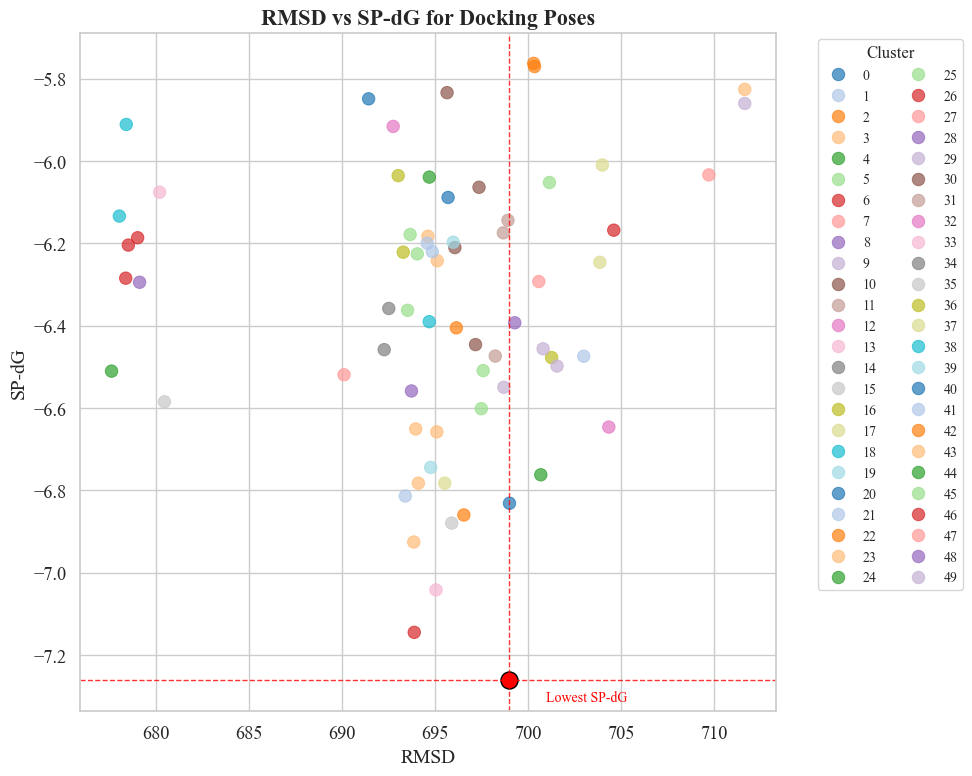

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
csv_file = "dimer_pose_data.csv"  # 替换为你的 CSV 文件路径
df = pd.read_csv(csv_file)

# 提取最低 SP-dG 的点
min_spdg_row = df.loc[df['spdg'].idxmin()]

# 设置绘图风格
sns.set(style="whitegrid", context="notebook", font_scale=1.2)

# 计算动态 figsize
unique_clusters = df['cluster_num'].nunique()
fig_width = 10
fig_height = 8

plt.figure(figsize=(fig_width, fig_height))

# 设置全局字体
plt.rcParams['font.family'] = 'Times New Roman'

# 创建散点图
scatter_plot = sns.scatterplot(
    data=df, 
    x='rmsd', 
    y='spdg', 
    hue='cluster_num', 
    palette='tab20',  # 使用更多颜色的调色板
    s=80, 
    alpha=0.7, 
    edgecolor=None
)

# 突出显示最低 SP-dG 的点
plt.scatter(
    min_spdg_row['rmsd'], 
    min_spdg_row['spdg'], 
    color='red', 
    s=150, 
    label='Lowest SP-dG', 
    edgecolor='black'
)

# 添加辅助线标注关键点
plt.axvline(x=min_spdg_row['rmsd'], color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.axhline(y=min_spdg_row['spdg'], color='red', linestyle='--', linewidth=1, alpha=0.8)
plt.text(
    min_spdg_row['rmsd'] + 2, 
    min_spdg_row['spdg'] - 0.05, 
    'Lowest SP-dG', 
    color='red', 
    fontsize=10
)

# 设置标题和轴标签
plt.title('RMSD vs SP-dG for Docking Poses', fontsize=16, fontweight='bold')
plt.xlabel('RMSD', fontsize=14)
plt.ylabel('SP-dG', fontsize=14)

# 调整图例布局：自动分多列
handles, labels = scatter_plot.get_legend_handles_labels()
handles = handles[:-1]  # 移除最后一个句柄（Lowest SP-dG）
labels = labels[:-1] 
plt.legend(
    handles=handles, 
    labels=labels, 
    title="Cluster", 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    fontsize=10, 
    title_fontsize=12, 
    frameon=True,
    ncol=2  # 根据需要动态调整列数
)

# 调整布局
plt.tight_layout()
plt.show()

/var/folders/9r/x839d7_53yj5gjbnnx1w58h40000gn/T/ipykernel_32847/1946043218.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=analysis_df, x='cluster_num', y='member_energy', palette='Set3', cut=0)


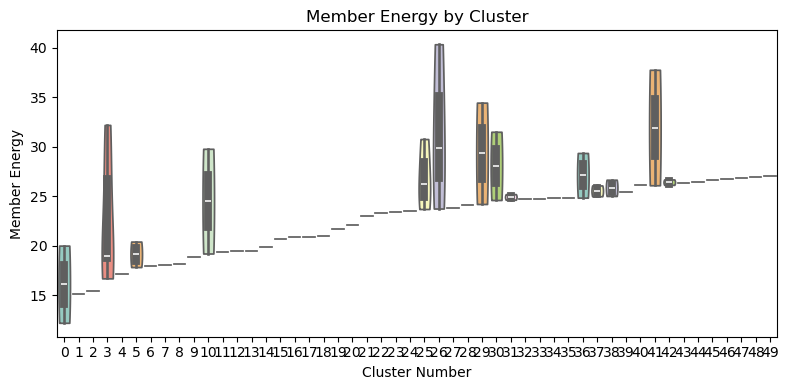

In [10]:
plt.figure(figsize=(8,4))
sns.violinplot(data=analysis_df, x='cluster_num', y='member_energy', palette='Set3', cut=0)
plt.title('Member Energy by Cluster')
plt.xlabel('Cluster Number')
plt.ylabel('Member Energy')
plt.tight_layout()
plt.show()

/var/folders/9r/x839d7_53yj5gjbnnx1w58h40000gn/T/ipykernel_32847/172389400.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


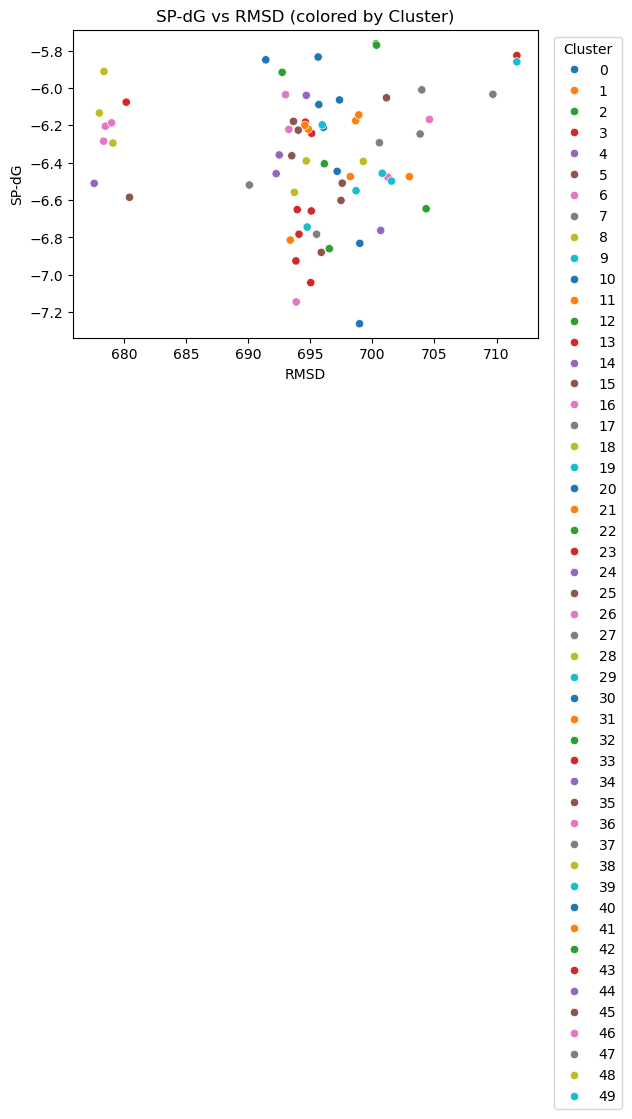

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=analysis_df, x='rmsd', y='spdg', hue='cluster_num', palette='tab10')
plt.title('SP-dG vs RMSD (colored by Cluster)')
plt.xlabel('RMSD')
plt.ylabel('SP-dG')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
fig = px.scatter_3d(
    analysis_df,
    x='rmsd',
    y='spdg',
    z='member_energy',
    color='cluster_num',
    symbol='cluster_member',  # 可选
    hover_name='file_name',
    title='3D Scatter: RMSD vs SP-dG vs Member Energy'
)
fig.update_layout(
    legend=dict(x=0.01, y=0.99),
    scene=dict(
        xaxis_title='RMSD',
        yaxis_title='SP-dG',
        zaxis_title='Member Energy'
    )
)
fig.show()